# 4. The Iliadis (2002)-style sensitivity sweep

Once you've found an interesting isotope (notebook 3), the next question is
"how sensitive is it to a specific reaction's rate?" This notebook covers
`PPNSweep` — a directory of single-reaction-at-a-time rate factor runs — and
the sensitivity analysis built on top of it.

The whole algorithm is a post-hoc ratio: every tested factor is already a
completed, independent single-zone run (built by `tools/build_sweep.jl`, see
its `README.md`); sensitivity is just `X(factor) / X(baseline)`.

This notebook uses a **tiny synthetic fixture** (`test/data/sweep/`, one
reaction, two factors) so it's self-contained — just enough to exercise
every function. A real sweep, with many reactions and factors, is read the
same way: `PPNSweep(path_to_your_runs_dir)`.

In [1]:
using Pkg
Pkg.activate(joinpath(@__DIR__, ".."))
using NuGridJl

SWEEP_DIR = joinpath(@__DIR__, "..", "test", "data", "sweep")
sweep = PPNSweep(SWEEP_DIR)

  Activating 

project at `~/Documents/NovaNucleosynthesis/NuGrid-Tools/NuGridJl`


PPNSweep("/home/sgervais/Documents/NovaNucleosynthesis/NuGrid-Tools/NuGridJl/demos/../test/data/sweep", 1 reactions, 2 factored runs)

In [2]:
reactions(sweep), factors(sweep, "13N_pg_14O")

(["13N_pg_14O"], [0.5, 2.0])

## Sensitivity of one isotope to one reaction

`sensitivity(sweep, reaction, isotope)` returns `factor => ratio` for every
tested factor of that reaction.

In [3]:
sensitivity(sweep, "13N_pg_14O", "He-4")

Dict{Float64, Float64} with 2 entries:
  2.0 => 1.42676
  0.5 => 0.634113

## The full table

`sensitivity_table` does this for every reaction in the sweep and every
isotope you ask about, in long format (one row per reaction×isotope×factor).
`iliadis_table` reshapes the same data wide — one column per factor, the
literal "Iliadis (2002) Table 8" layout.

In [4]:
table = sensitivity_table(sweep, "He-4")

Row,reaction,isotope,factor,ratio
,String,String,Float64,Float64
1,13N_pg_14O,He-4,0.5,0.634113
2,13N_pg_14O,He-4,2.0,1.42676


In [5]:
iliadis_table(sweep, "He-4")

Row,reaction,isotope,0.5,2.0
,String,String,Float64?,Float64?
1,13N_pg_14O,He-4,0.634113,1.42676


## Ranking reactions

`rank_reactions` sorts by `max(|log10(ratio)|)` across every tested factor —
the biggest swing away from baseline, regardless of which factor or
direction caused it. With only one reaction in this fixture the ranking
isn't interesting yet, but this is exactly what you'd run across a real
multi-reaction sweep to find your most sensitive reactions.

In [6]:
rank_reactions(table, "He-4")

Row,reaction,score
,String,Float64
1,13N_pg_14O,0.197833


## Plotting it

`sensitivity_plot` — log-log ratio vs. factor, one line per isotope, with a
reference line at ratio = 1.

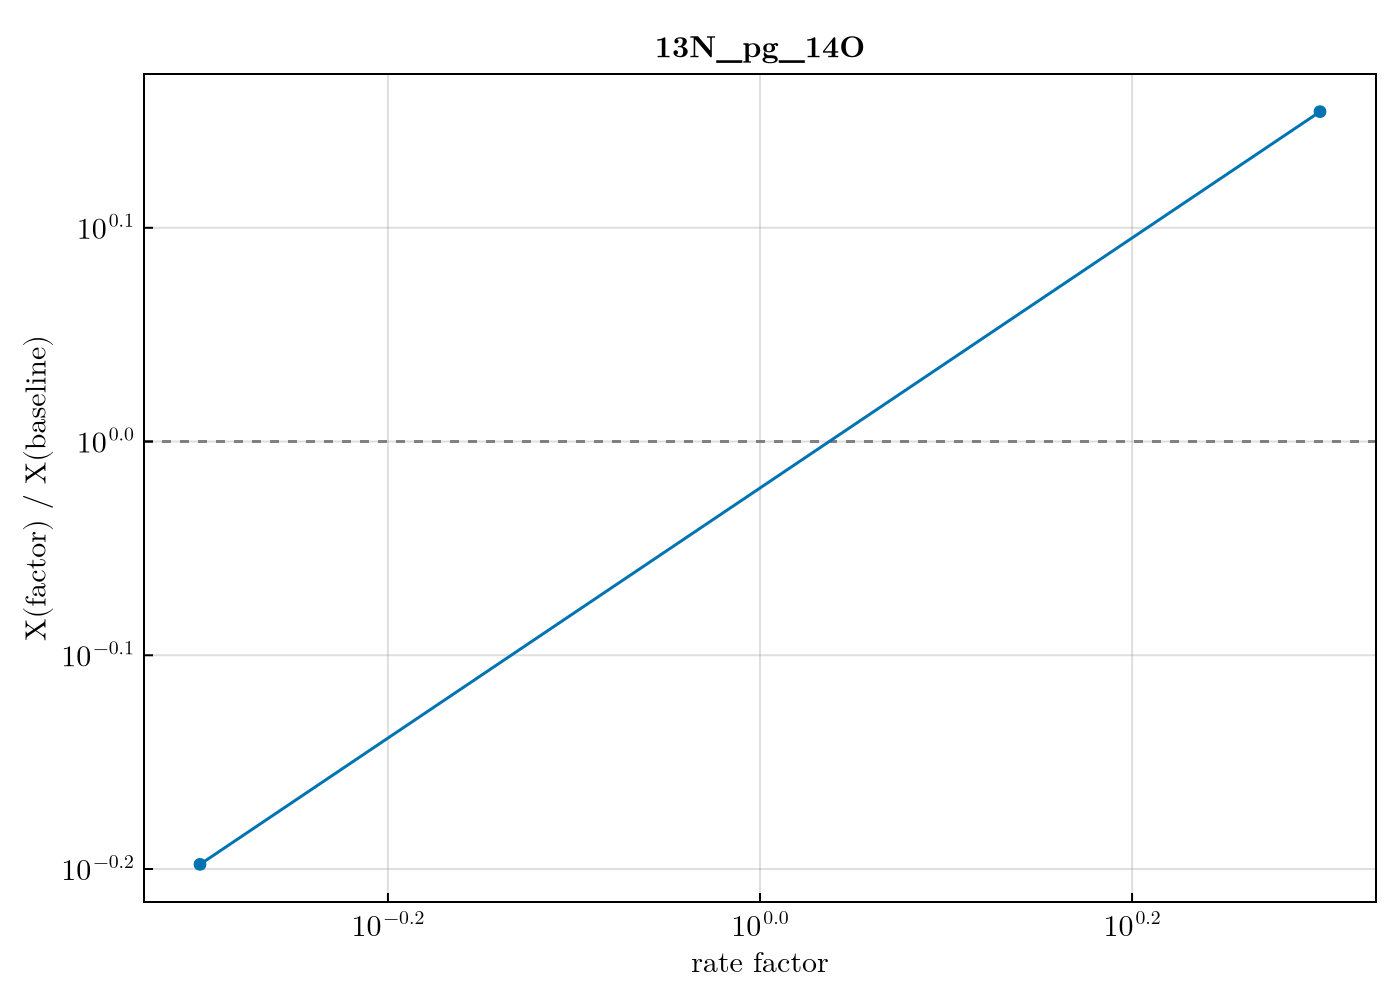

In [7]:
sensitivity_plot(sweep, "13N_pg_14O", "He-4")

## Where does the rate come from?

`describe_rate` (notebook 1) already tells you the source label and printed
rate straight from `networksetup.txt` — no NPDATA lookup needed for that.
NPDATA is for the next question: what does that rate look like as a function
of temperature, and are there other evaluations of it on file? `rate_curve`/
`rate_plot` search every REACLIB file under an NPDATA directory for a
reaction's rate curve(s).

We use another small bundled fixture here (`test/data/npdata_test/`, one
reaction) purely to demonstrate the mechanism — point `rate_curve` at a real
`NPDATA/` directory for actual physics.

In [8]:
NUPPN = joinpath(@__DIR__, "..", "test", "data", "nuppn_data")
NPDATA_FIXTURE = joinpath(@__DIR__, "..", "test", "data", "npdata_test")

net = network(PPNRun(NUPPN))
r154 = only(filter(r -> r.index == 154, net.reactions))
describe_rate(r154)

"12C(p,g)13N        source=NACRR  rate=5.6300e-22  x1"

In [9]:
rate_curve(r154, NPDATA_FIXTURE)

Row,T9,rate,label,file,chapter,qvalue
,Float64,Float64,String,String,Int64,Float64
1,0.01,22026.5,nacrr,synthetic_reaclib.txt,4,1.943
2,0.0102337,22026.5,nacrr,synthetic_reaclib.txt,4,1.943
3,0.0104729,22026.5,nacrr,synthetic_reaclib.txt,4,1.943
4,0.0107177,22026.5,nacrr,synthetic_reaclib.txt,4,1.943
5,0.0109682,22026.5,nacrr,synthetic_reaclib.txt,4,1.943
6,0.0112245,22026.5,nacrr,synthetic_reaclib.txt,4,1.943
7,0.0114868,22026.5,nacrr,synthetic_reaclib.txt,4,1.943
8,0.0117553,22026.5,nacrr,synthetic_reaclib.txt,4,1.943
9,0.0120301,22026.5,nacrr,synthetic_reaclib.txt,4,1.943


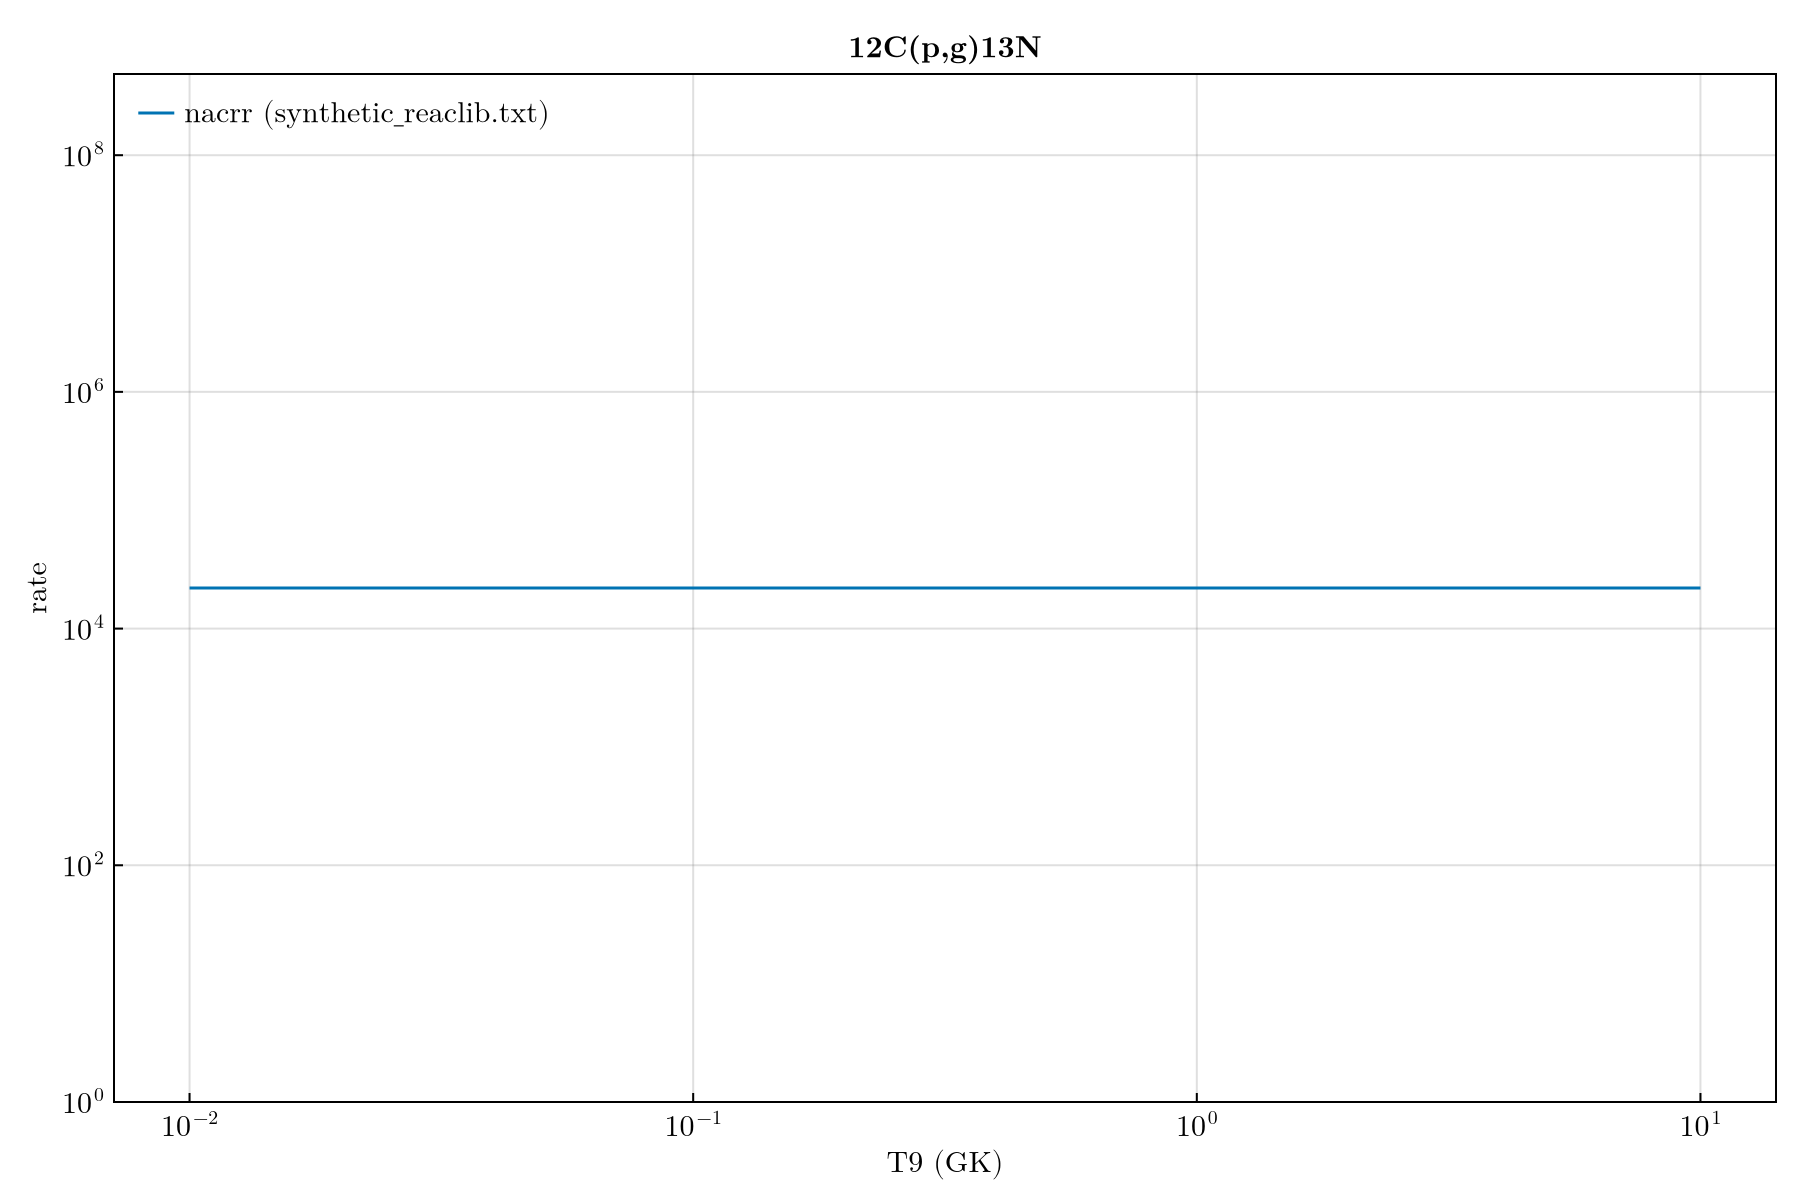

In [10]:
rate_plot(r154, NPDATA_FIXTURE)

## Next

[`05_reaction_reporting.ipynb`](05_reaction_reporting.ipynb) — turn all of
this into the two reaction lists a sensitivity study is meant to produce:
what mattered in the baseline, and what turned out sensitive.